# Offline-Auswertung einer ERP-Sitzung

Wertet eine aufgezeichnete CSV nachträglich aus — mit **nullphasiger Filterung
(`filtfilt`)** statt des fortlaufenden IIR-Filters, der im Betrieb nötig ist.

Die Epochierung stammt aus denselben Klassen wie die Live-Anwendung
(`core.ERPProcessor`, `core.TFRProcessor`). `offline.replay()` treibt sie in
derselben Reihenfolge an wie `gui/main_window._update_plots()`, damit Notebook
und Anwendung nicht auseinanderlaufen können.

**Ablauf:** Aufnahme wählen → Filter entwerfen → Signal sichten → Durchlauf →
ERP/TFR → Parameter variieren → sichern.

## 1 · Vorbereitung

In [1]:
%load_ext autoreload
%autoreload 2

import sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook liegt im Projektstamm; sonst hier den Pfad dorthin eintragen.
ROOT = pathlib.Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from offline import (load_session, list_sessions, channel_report,
                     OfflineFilter, epoch_stats, select_triggers, replay,
                     plot_erp, plot_erp_grid, plot_tfr, plot_raw,
                     plot_selection, use_app_style)

use_app_style(dark=True)     # dark=False -> heller Hintergrund zum Drucken
pd.set_option("display.width", 140)

## 2 · Aufnahme wählen

Übersicht, ohne die Dateien ganz zu laden.

In [2]:
list_sessions("recordings").sort_values("trigger", ascending=False).head(15)

,datei,dauer_s,samples,trigger,mb
11,ERP_20260813_120505.csv,899.8,224950,91,40.9
8,ERP_20260813_115015.csv,653.0,162296,74,29.6
13,ERP_20260813_122821_keinReiz.csv,499.5,124874,68,22.5
23,ERP_20260813_131731_stimulationFuss.csv,315.8,78940,47,14.2
17,ERP_20260813_124625_stimulationDaumen.csv,288.8,72203,47,13.0
19,ERP_20260813_125428_stimulationOberarm.csv,279.6,69900,46,12.6
12,ERP_20260813_122235_nurAkustisch.csv,257.8,64447,40,11.6
6,ERP_20260813_112224.csv,188.7,47166,33,8.4
3,ERP_20260813_111014.csv,138.5,34535,24,6.4
20,ERP_20260813_131259.csv,115.4,28857,19,5.2


In [3]:
CSV = "examples/sample_recording/ERP_demo_stimulation.csv"

ses = load_session(CSV)
print(ses)
print("Kanäle:", ses.ch_labels)
print("Trigger-Nummern:", ses.trigger_values.astype(int))
ses.meta

<Session ERP_20260813_131731_stimulationFuss.csv: 78940 Samples / 315.8s, 47 Trigger, 0 verlorene Samples>
Kanäle: ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'PO7', 'Oz', 'PO8']
Trigger-Nummern: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47]


{}

## 3 · Rohsignal beurteilen

Der Unicorn liefert Rohwerte mit sehr großem Gleichanteil (Größenordnung
10⁵ µV). `anschlag_%` zeigt Samples am Anschlagwert ±750000 µV, `konstant_%`
unveränderte Nachbarsamples — beides deutet auf eine abgerissene Elektrode
hin. Solche Kanäle vor der Auswertung ausschließen, besonders wenn sie in der
TFR-ROI liegen.

In [4]:
channel_report(ses.raw, ses.ch_labels)

,mittel,std,p99_abs,max_abs,anschlag_%,konstant_%
kanal,,,,,,
Fz,185906.2,7589.9,186079.5,750000.0,0.01,1.04
C3,197937.2,6292.3,198010.6,750000.0,0.01,0.86
Cz,209997.9,7398.9,221052.1,750000.0,0.01,0.97
C4,243278.1,10583.1,267428.3,750000.0,0.01,0.81
Pz,189298.7,7922.8,189454.7,750000.0,0.02,1.08
PO7,191719.0,7231.6,191855.6,750000.0,0.01,1.02
Oz,188820.8,7310.7,189031.6,750000.0,0.01,1.19
PO8,184756.7,6592.2,184778.3,750000.0,0.01,0.96


## 4 · Filter entwerfen

`OfflineFilter` verwendet dieselben Filterentwürfe wie `utils/filters.py`
(Butterworth, IIR-Notch), läuft sie aber mit `sosfiltfilt` vorwärts **und**
rückwärts durch. Ergebnis: keine Phasenverschiebung, kein Einschwingen —
dafür effektiv doppelte Ordnung.

Reihenfolge wie in der Anwendung: erst Hochpass, dann Notch. Der Tiefpass ist
auskommentiert; für reine ERP-Auswertung sinnvoll, für die TFR bis 50 Hz nicht.

<OfflineFilter fs=250 Hz, filtfilt: Hochpass 1.0 Hz (Ord. 4) → Notch 50 Hz (Q=30)>


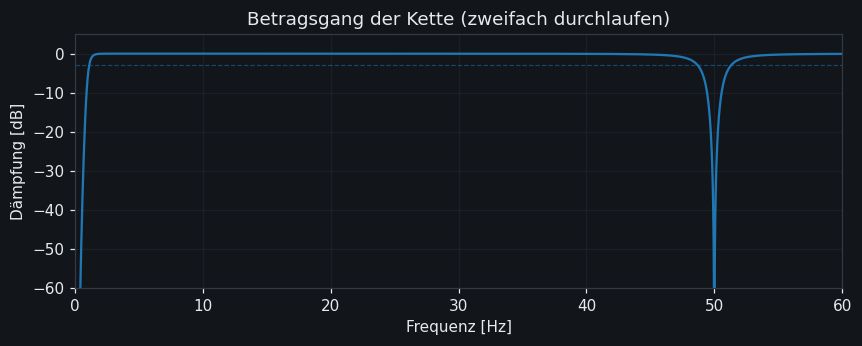

In [5]:
FS = ses.fs

flt = (OfflineFilter(fs=FS)
       .highpass(1.0, order=4)          # Drift / Gleichanteil entfernen
       .notch(50.0, q=30, harmonics=1)  # harmonics=2 nimmt 100 Hz mit
       # .lowpass(40.0, order=4)
       )
print(flt)

f, db = flt.frequency_response()
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(f, db, lw=1.5)
ax.axhline(-3, ls="--", lw=0.8, alpha=0.5)
ax.set_xlim(0, 60); ax.set_ylim(-60, 5)
ax.set_xlabel("Frequenz [Hz]"); ax.set_ylabel("Dämpfung [dB]")
ax.set_title("Betragsgang der Kette (zweifach durchlaufen)")
ax.grid(alpha=0.3)

In [6]:
eeg = flt(ses.raw)                    # (samples, 8), µV
channel_report(eeg, ses.ch_labels)

,mittel,std,p99_abs,max_abs,anschlag_%,konstant_%
kanal,,,,,,
Fz,-44.6,4423.6,62.6,215002.9,0.0,0.0
C3,6.3,4808.5,38.6,425913.8,0.0,0.0
Cz,84.8,7046.6,73.7,618301.4,0.0,0.0
C4,74.1,6268.2,67.7,471552.9,0.0,0.0
Pz,-56.4,4732.2,59.4,203036.6,0.0,0.0
PO7,10.6,4457.6,39.6,356131.3,0.0,0.0
Oz,-51.7,4498.9,50.9,344519.5,0.0,0.0
PO8,59.1,5988.4,47.2,527719.4,0.0,0.0


## 5 · Signal sichten

Vor jeder Mittelung einmal hinsehen: liegen die Trigger dort, wo sie sollen,
und wie stark sind die Artefakte? `p99_abs` oben und `max_abs` liegen bei
diesen Aufnahmen um Größenordnungen auseinander — das Signal ist überwiegend
sauber, mit wenigen sehr großen Einbrüchen.

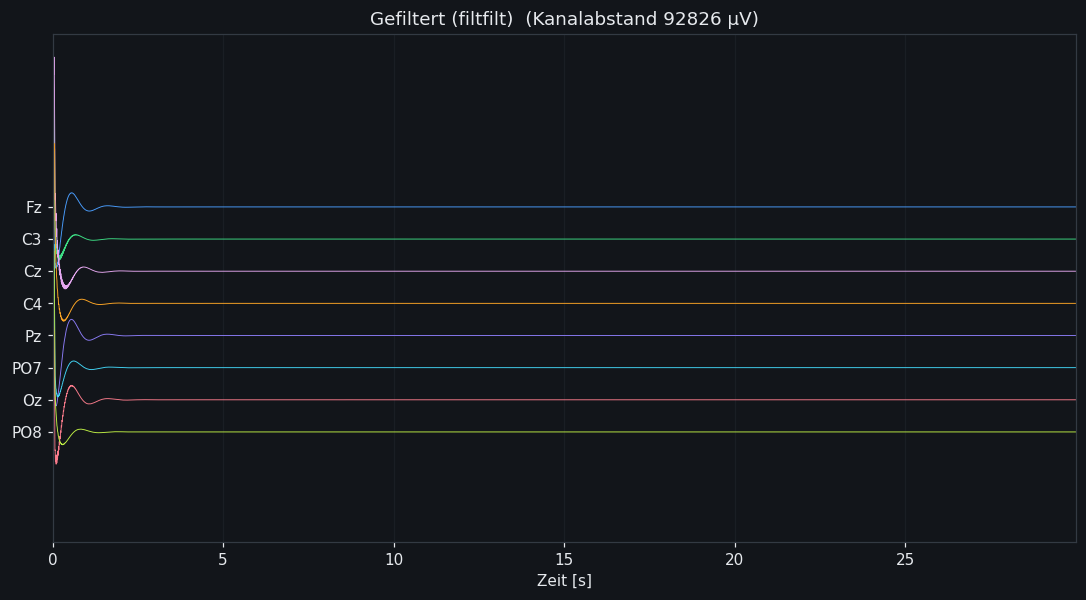

In [7]:
sl = slice(0, int(30 * FS))           # erste 30 s
plot_raw(ses.t[sl], eeg[sl], ses.ch_labels,
         trigger_t=ses.t[ses.trigger_idx],
         title="Gefiltert (filtfilt)");

### Nullphasig gegen fortlaufend

Zum Vergleich das, was die Anwendung live gerechnet hat (`flt_*`-Spalten der
CSV) gegen die Offline-Filterung. Der sichtbare Zeitversatz ist die Laufzeit
des kausalen Filters — genau das, was offline entfällt.

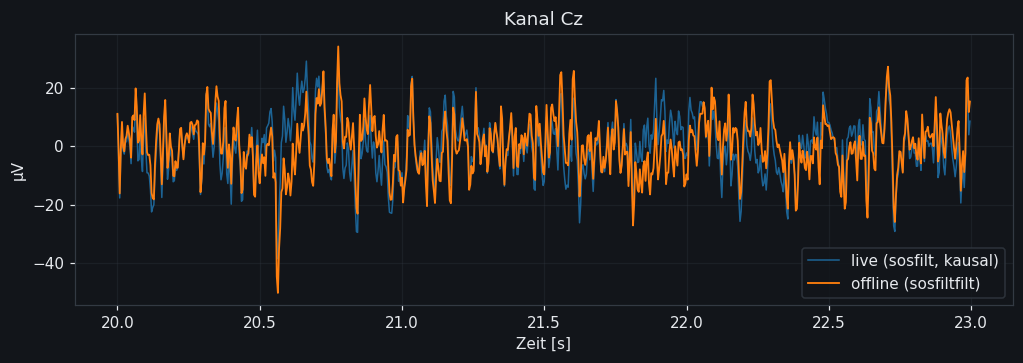

In [8]:
ch = ses.ch_labels.index("Cz")
sl = slice(int(20 * FS), int(23 * FS))

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(ses.t[sl], ses.flt[sl, ch], lw=1.0, alpha=0.8, label="live (sosfilt, kausal)")
ax.plot(ses.t[sl], eeg[sl, ch],     lw=1.2,            label="offline (sosfiltfilt)")
ax.set_xlabel("Zeit [s]"); ax.set_ylabel("µV")
ax.set_title(f"Kanal {ses.ch_labels[ch]}"); ax.legend(); ax.grid(alpha=0.3)

## 6 · Trigger auswählen

Zwei Fragen, die getrennt gehören:

**Welcher Abschnitt der Sitzung?** Am Anfang sitzt die Person noch nicht
ruhig und die Elektroden sind nicht eingelaufen. `last=40` nimmt nur die
letzten 40 Trigger. Das ist zulässig, solange man es dazusagt — es ist eine
Einschränkung der Aussage, keine Verbesserung der Daten.

**Welche Epochen sind brauchbar?** Die feste Grenze von 100 µV der App ist
eine Annahme über den Amplitudenmaßstab, und der ändert sich zwischen
Sitzungen. `mad_k=3.5` verwirft stattdessen, was für *diese* Aufnahme
untypisch ist: mehr als 3,5 robuste Standardabweichungen über dem Median,
gerechnet auf dem Logarithmus, weil Artefaktamplituden stark rechtsschief
verteilt sind.

Vorher ansehen, was die Auswahl täte — `replay()` macht intern genau das:

In [9]:
st = epoch_stats(eeg, ses.trigger_idx, fs=FS, pre_ms=200, post_ms=2000,
                 ch_labels=ses.ch_labels)
st = select_triggers(st, last=40, mad_k=3.5)
print(st["grund"].value_counts().to_string())
st.tail(12)

grund
gewählt              39
nicht gewählt         7
Ausreißer (z=3.9)     1


,nr,sample,t_s,vollstaendig,max_abs,ptp,rms,basis_drift,worst_ch,mad_z,gewaehlt,grund
35,36,62350,249.400,True,29.24,49.99,7.57,3.69,Cz,-0.47,True,gewählt
36,37,63903,255.612,True,25.34,43.34,6.13,6.32,C3,-0.80,True,gewählt
37,38,64698,258.792,True,33.98,50.28,8.67,15.21,Fz,-0.12,True,gewählt
38,39,65754,263.016,True,30.36,44.67,6.07,5.95,PO7,-0.38,True,gewählt
39,40,67068,268.272,True,56.72,85.20,10.17,1.78,Fz,1.07,True,gewählt
40,41,68873,275.492,True,58.01,78.66,7.51,22.67,C4,1.13,True,gewählt
41,42,70424,281.696,True,47.32,73.16,9.01,10.31,Fz,0.65,True,gewählt
42,43,72224,288.896,True,66.20,111.51,9.63,5.08,C4,1.43,True,gewählt
43,44,73783,295.132,True,195.24,267.43,27.67,27.71,Cz,3.94,False,Ausreißer (z=3.9)
44,45,74575,298.300,True,101.27,181.37,22.35,24.83,Fz,2.42,True,gewählt


## 7 · Durchlauf

`replay()` schiebt das gefilterte Signal blockweise durch `ERPProcessor` und
`TFRProcessor` und setzt bei jedem gewählten Trigger `on_trigger()` ab. Das
Trigger-Sample ist das erste Sample **nach** dem Reiz, also t = 0.

`post_ms=2000` für späte Komponenten. Das geht nur, solange der Abstand
zwischen zwei Reizen größer als das Fenster ist — sonst greift der
Doppel-Trigger-Schutz und verwirft die Hälfte der Epochen. Bei diesen
Aufnahmen liegt der kleinste Abstand bei etwa 3,1 s, ein Fenster bis
2000 ms passt also.

`threshold=None` schaltet die feste µV-Grenze ab, weil `mad_k` die Aufgabe
schon übernimmt. Beides zusammen geht auch.

In [10]:
res = replay(
    eeg, ses.trigger_idx, fs=FS,
    pre_ms=200, post_ms=2000,         # langes ERP-Fenster
    last=40,                          # nur die letzten 40 Trigger
    mad_k=3.5,                        # robuste Ausreißergrenze
    threshold=None,                   # feste µV-Grenze aus
    with_tfr=True,
    tfr_pre_ms=1500, tfr_post_ms=3500,
    tfr_roi=(0, 2, 4),                # Fz, Cz, Pz
    ch_labels=ses.ch_labels,
    label=pathlib.Path(CSV).stem,
)
res

<ReplayResult ERP_20260813_131731_stimulationFuss -200…2000 ms · ERP: 39 akzeptiert / 0 abgelehnt, TFR: 36 [39/47 Trigger gewählt]>

### Was mit jedem Trigger passiert ist

* **akzeptiert** – Epoche ging in die Mittelung ein
* **nicht gewählt** – außerhalb von `last`/`first`/`subset`
* **Ausreißer (z=…)** – von `mad_k` verworfen
* **abgelehnt** – über der festen µV-Grenze
* **ignoriert** – kam, während die vorige Epoche noch lief (Doppel-Trigger)
* **unvollständig** – Nachfenster reichte über das Dateiende hinaus

Weil verworfene Trigger gar nicht erst gemeldet werden, wächst der Abstand
zwischen den verbleibenden — dadurch fallen weniger Epochen dem
Doppel-Trigger-Schutz zum Opfer als bei einer Abweisung im Prozessor.

Die TFR hat meist weniger Epochen als das ERP: ihr Fenster ist mit 3,5 s
deutlich länger, entsprechend mehr Trigger fallen als Doppel-Trigger weg.

In [11]:
print(res.triggers["status"].value_counts().to_string())
print(f"\nERP: {res.n_accepted} akzeptiert / {res.n_rejected} abgelehnt")
print(f"TFR: {res.tfr.n_epochs} Epochen")
res.triggers

status
akzeptiert           39
nicht gewählt         7
Ausreißer (z=3.9)     1

ERP: 39 akzeptiert / 0 abgelehnt
TFR: 36 Epochen


,nr,sample,t_s,max_abs,ptp,rms,basis_drift,worst_ch,mad_z,status
0,1,11458,45.832,101.64,145.45,13.21,10.71,Fz,2.43,nicht gewählt
1,2,13257,53.028,60.48,84.60,7.24,8.10,Cz,1.22,nicht gewählt
2,3,14327,57.308,30.25,54.83,6.87,7.24,C3,-0.39,nicht gewählt
3,4,16119,64.476,32.02,60.35,6.89,9.16,C3,-0.25,nicht gewählt
4,5,17684,70.736,20.33,37.73,5.92,7.97,Oz,-1.31,nicht gewählt
5,6,18470,73.880,21.16,38.99,6.06,6.28,Cz,-1.22,nicht gewählt
6,7,19526,78.104,28.55,56.18,6.92,8.10,Cz,-0.52,nicht gewählt
7,8,20844,83.376,40.15,62.75,6.83,13.92,C4,0.27,akzeptiert
8,9,22647,90.588,38.39,54.67,7.09,6.52,Cz,0.17,akzeptiert
9,10,24456,97.824,58.45,91.75,8.32,1.91,C4,1.14,akzeptiert


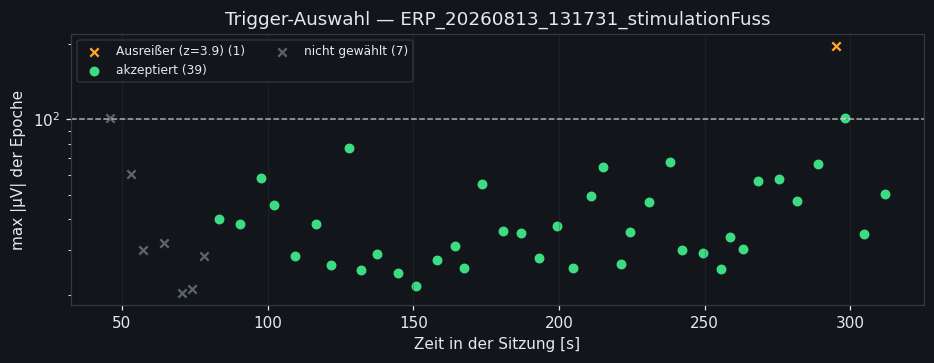

In [12]:
plot_selection(res, threshold=100.0);

## 8 · ERP

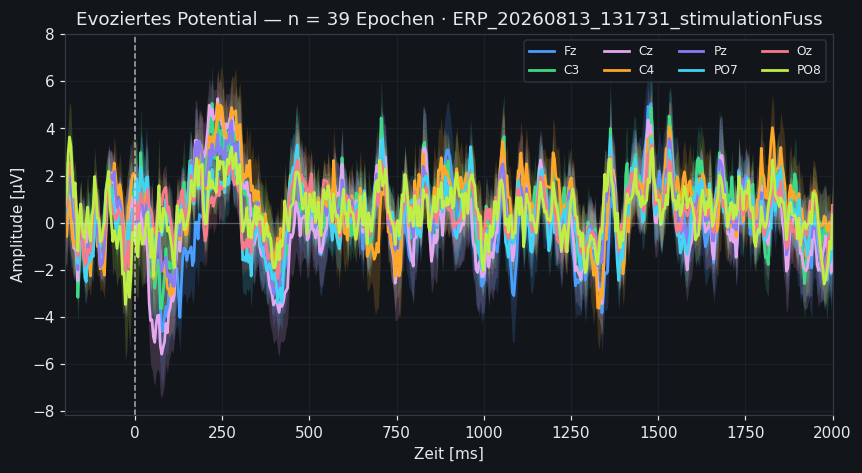

In [13]:
plot_erp(res, sem=True);

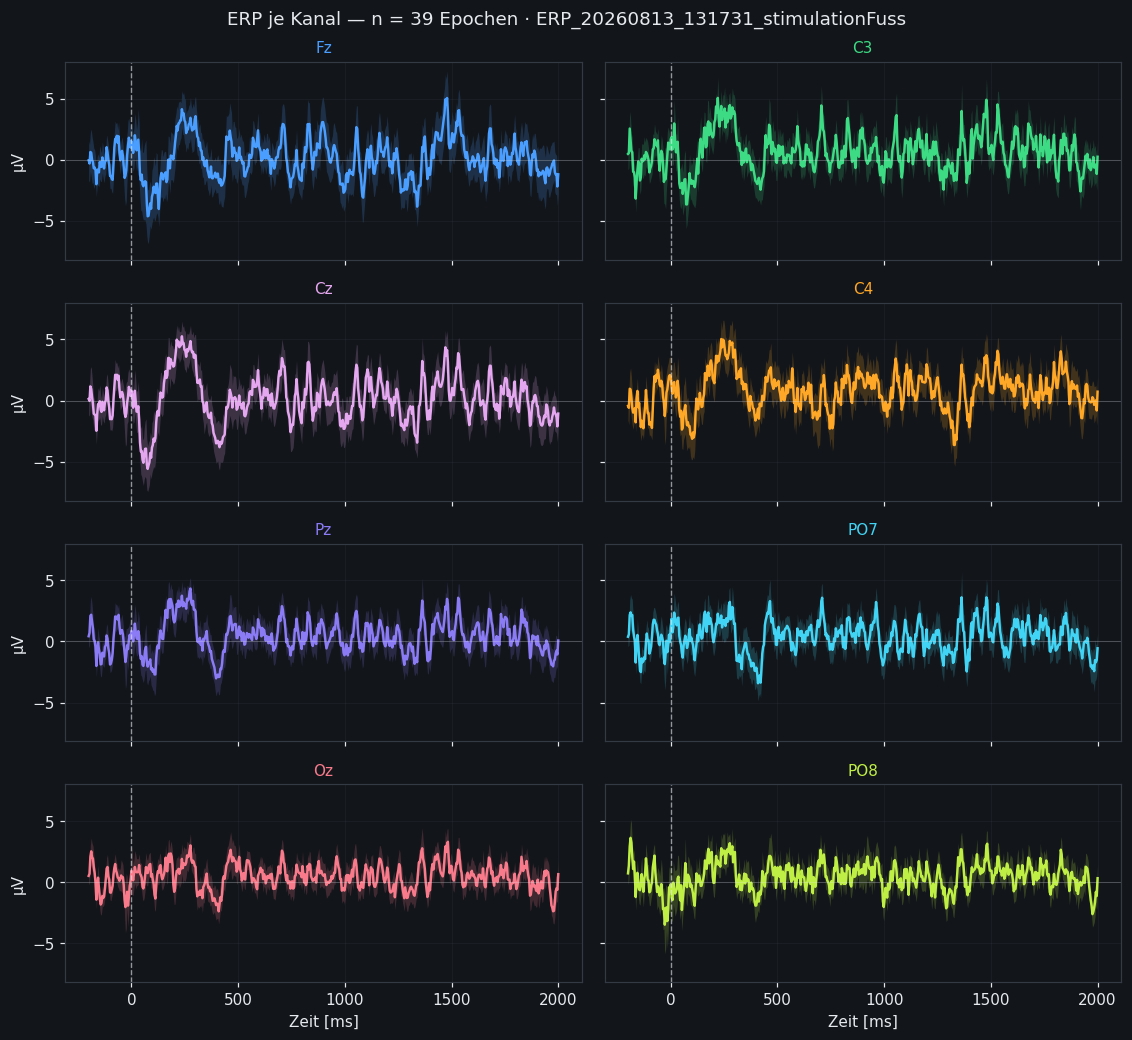

In [14]:
plot_erp_grid(res, sem=True, ncols=2);

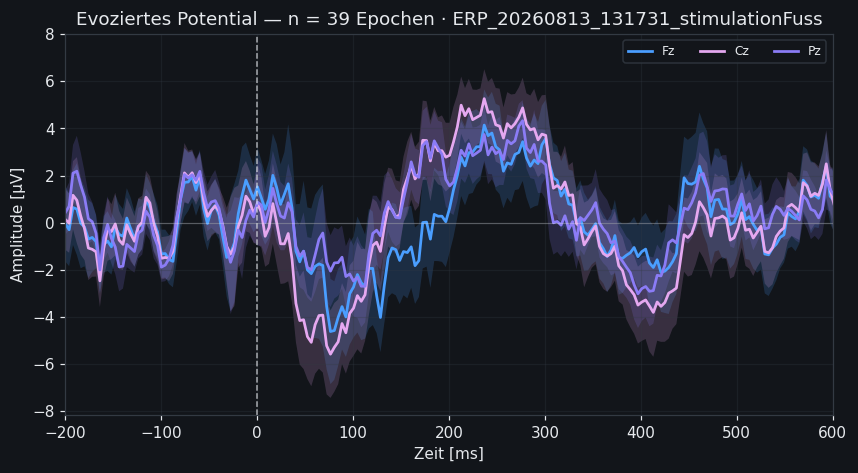

In [15]:
# Einzelne Kanäle, engerer Ausschnitt
plot_erp(res, channels=["Fz", "Cz", "Pz"], sem=True, xlim=(-200, 600));

## 9 · Zeit-Frequenz

Aufbau wie in der Anwendung: oben 10–50 Hz (STFT-Fenster 200 ms), unten
1–10 Hz (Fenster 1000 ms), beides als z-Score gegen die Grundlinie von
−1,0 s bis −0,2 s.

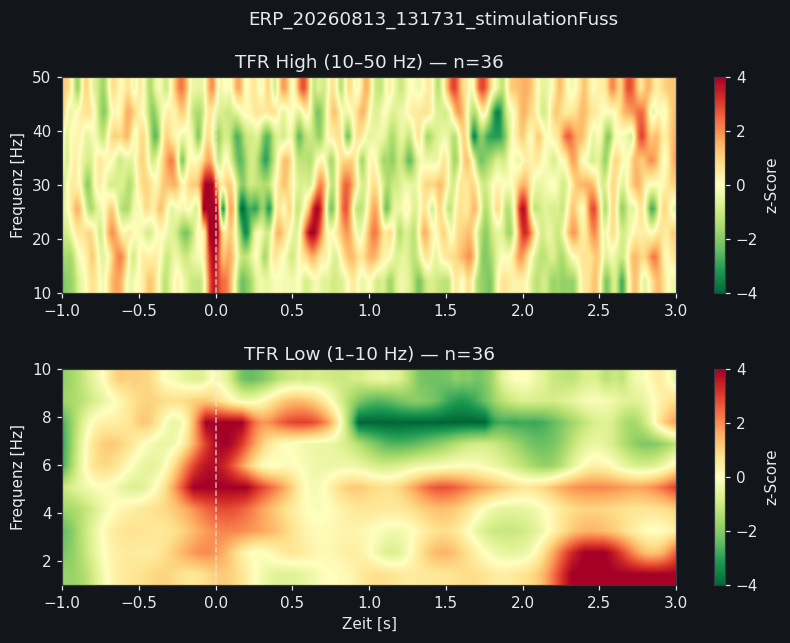

In [16]:
plot_tfr(res);

## 10 · Parameter variieren

Der eigentliche Gewinn der Offline-Auswertung: dieselbe Aufnahme mehrfach mit
unterschiedlichen Einstellungen durchrechnen und nebeneinanderlegen. Hier die
Hochpass-Grenzfrequenz — sie bestimmt, wie viel langsame Drift stehen bleibt
und wie stark späte Komponenten beschnitten werden.

In [ ]:
CH = "Cz"
varianten = [0.1, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(10, 4.5))
for hp in varianten:
    f_var = OfflineFilter(fs=FS).highpass(hp).notch(50.0)
    r_var = replay(f_var(ses.raw), ses.trigger_idx, fs=FS,
                   pre_ms=200, post_ms=2000, last=40, mad_k=3.5,
                   threshold=None, with_tfr=False, ch_labels=ses.ch_labels)
    i = ses.ch_labels.index(CH)
    ax.plot(r_var.time_axis, r_var.erp_mean[:, i], lw=1.6,
            label=f"HP {hp} Hz  (n={r_var.n_accepted})")

ax.axvline(0, ls="--", lw=1, alpha=0.6); ax.axhline(0, lw=0.8, alpha=0.3)
ax.set_xlabel("Zeit [ms]"); ax.set_ylabel("µV")
ax.set_title(f"Kanal {CH} — Einfluss der Hochpass-Grenzfrequenz")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

### Mehrere Aufnahmen vergleichen

Gleiche Filterkette, gleiche Parameter, unterschiedliche Sitzungen.

In [ ]:
DATEIEN = [
    "examples/sample_recording/ERP_demo_stimulation.csv",
    # "recordings/ERP_20260813_125428_stimulationOberarm.csv",
]

ergebnisse = {}
for p in DATEIEN:
    s = load_session(p)
    if len(s.trigger_idx) == 0:
        print(f"übersprungen (keine Trigger): {p}")
        continue
    f_i = OfflineFilter(fs=s.fs).highpass(1.0).notch(50.0)
    ergebnisse[pathlib.Path(p).stem] = replay(
        f_i(s.raw), s.trigger_idx, fs=s.fs, pre_ms=200, post_ms=2000,
        last=40, mad_k=3.5, threshold=None, with_tfr=False,
        ch_labels=s.ch_labels, label=pathlib.Path(p).stem)

fig, ax = plt.subplots(figsize=(10, 4.5))
for name, r in ergebnisse.items():
    i = r.ch_labels.index(CH)
    ax.plot(r.time_axis, r.erp_mean[:, i], lw=1.6, label=f"{name} (n={r.n_accepted})")
ax.axvline(0, ls="--", lw=1, alpha=0.6); ax.axhline(0, lw=0.8, alpha=0.3)
ax.set_xlabel("Zeit [ms]"); ax.set_ylabel("µV"); ax.set_title(f"Kanal {CH}")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

Für die Gegenüberstellung mehrerer Bedingungen mit Latenzmaßen und
Statistik gibt es ein eigenes Notebook: `analyse_vergleich.ipynb`.

## 11 · Sichern

In [ ]:
OUT = pathlib.Path("analysen") / pathlib.Path(CSV).stem
OUT.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    OUT / "erp.npz",
    time_axis=res.time_axis, erp_mean=res.erp_mean, epochs=res.epochs,
    ch_labels=np.array(res.ch_labels),
)
if res.tfr is not None and res.tfr.P_total is not None:
    np.savez_compressed(
        OUT / "tfr.npz",
        t=res.tfr.t_all, f=res.tfr.f_all, P=res.tfr.P_total,
        n_lo=len(res.tfr.f_low), n_epochs=res.tfr.n_epochs,
    )
res.triggers.to_csv(OUT / "trigger.csv", index=False)

plot_erp(res, sem=True).figure.savefig(OUT / "erp.png", dpi=150, bbox_inches="tight")
plot_tfr(res)[0].savefig(OUT / "tfr.png", dpi=150, bbox_inches="tight")

print("gespeichert nach", OUT.resolve())
sorted(p.name for p in OUT.iterdir())